<a href="https://colab.research.google.com/github/Alenushka2013/ML_for_people_tasks/blob/main/HW_4_3_LSTM_for_time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1949-01 to 1960-12
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2+ KB


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
Passengers = df['Passengers'].values.astype(np.float32)
Passengers[:5]

array([112., 118., 132., 129., 121.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
data_size = Passengers.size
train_size = int(np.floor(0.67 * data_size))
train_data = Passengers[0:train_size]
val_data = Passengers[train_size:data_size] # або просто passengers_array_float32[train_size:]

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [5]:
import torch
def create_dataset(dataset, lookback):
  X, y = [], []
  for i in range(len(dataset) - lookback):
      feature = dataset[i:i + lookback]
      X.append(feature)

      target = dataset[i + lookback]
      y.append(target)

  X = torch.tensor(np.array(X), dtype=torch.float32)
  y = torch.tensor(np.array(y), dtype=torch.float32)

  y = y.unsqueeze(1)
  return X, y

In [6]:
lookback = 1
X_train, y_train = create_dataset(train_data, lookback=lookback)
X_test, y_test = create_dataset(val_data, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [7]:
import torch
import torch.nn as nn

class AirModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers):
        super(AirModel, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True)

        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):

        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        last_step_out = out[:, -1, :]
        prediction = self.linear(last_step_out)

        return prediction

model = AirModel(hidden_size=50, num_layers=1, input_size=lookback)

In [8]:
model(torch.tensor([[112.]]))

tensor([[0.1234]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [9]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [10]:
epochs = 2000
input_size = 1
hidden_size = 50
num_layers = 1

model = AirModel(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def rmse(preds, targets):
  rmse = torch.sqrt(loss_function(preds, targets) )
  return rmse

def train_model(model, dataloader, optimizer, criterion, epochs):

  losses = []

  for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in dataloader:

      optimizer.zero_grad()
      predictions = model(X_batch)
      loss = criterion(predictions, y_batch)

      loss.backward()
      optimizer.step()

      epoch_loss += loss.item() * len(X_batch)

    avg_epoch_loss = epoch_loss / len(dataloader.dataset)
    losses.append(avg_epoch_loss)

    if (epoch + 1) % 100 == 0:
      model.eval()

      with torch.no_grad():
        train_preds = model(X_train)
        train_rmse = rmse(train_preds, y_train)

        test_preds = model(X_test)
        test_rmse = rmse(test_preds, y_test)

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


  return losses

losses = train_model(model, train_loader, optimizer, loss_function, epochs)

Epoch 99: train RMSE 183.6349, test RMSE 378.0402
Epoch 199: train RMSE 149.1438, test RMSE 340.7221
Epoch 299: train RMSE 119.8140, test RMSE 307.0459
Epoch 399: train RMSE 96.5666, test RMSE 277.0495
Epoch 499: train RMSE 78.0219, test RMSE 250.0708
Epoch 599: train RMSE 62.0979, test RMSE 224.3086
Epoch 699: train RMSE 49.7650, test RMSE 201.0396
Epoch 799: train RMSE 41.1894, test RMSE 180.3387
Epoch 899: train RMSE 34.4941, test RMSE 162.5076
Epoch 999: train RMSE 30.8182, test RMSE 147.3812
Epoch 1099: train RMSE 27.6943, test RMSE 135.3982
Epoch 1199: train RMSE 26.3431, test RMSE 126.0829
Epoch 1299: train RMSE 25.2752, test RMSE 118.3423
Epoch 1399: train RMSE 25.4351, test RMSE 112.6051
Epoch 1499: train RMSE 24.1919, test RMSE 109.2083
Epoch 1599: train RMSE 23.8152, test RMSE 104.7993
Epoch 1699: train RMSE 23.6973, test RMSE 102.6861
Epoch 1799: train RMSE 24.9438, test RMSE 99.2043
Epoch 1899: train RMSE 24.0811, test RMSE 98.6936
Epoch 1999: train RMSE 24.2897, test RMSE

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

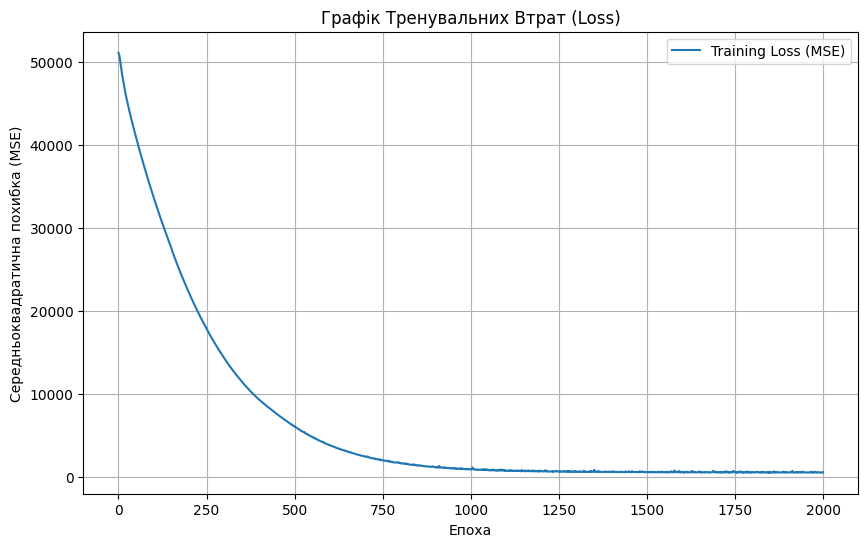

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss (MSE)')
plt.title('Графік Тренувальних Втрат (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Середньоквадратична похибка (MSE)')
plt.grid(True)
plt.legend()
plt.show()

**Спостереження:** Графік вказуює на вихід на плато значень похибки. При цьому значення функції втрат для тренувальних і тестувальних даних сильно відрізняються. Отже якість моделі поки ще незадовільна.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

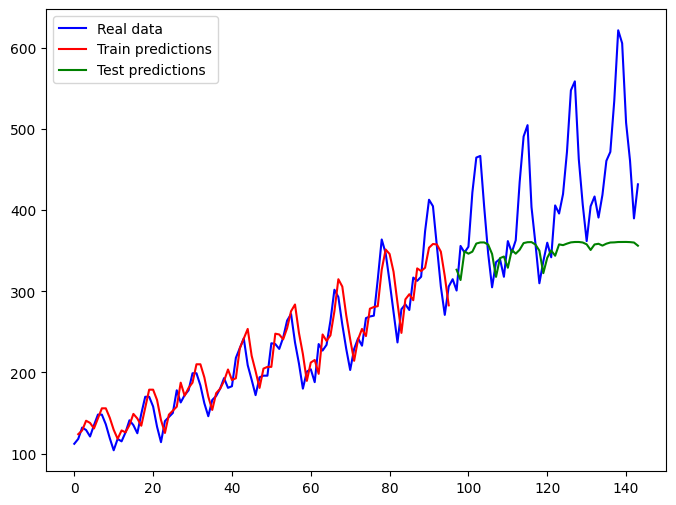

In [12]:
timeseries = df['Passengers'].values

def plot_predicts():
    model.eval()
    with torch.no_grad():
        # Прогнози для тренувальних даних
        train_plot = np.ones_like(timeseries) * np.nan
        y_pred_train = model(X_train).detach().cpu().numpy()[:, -1]
        train_plot[lookback:train_size] = y_pred_train

        # Прогнози для тестових даних
        test_plot = np.ones_like(timeseries) * np.nan
        y_pred_test = model(X_test).detach().cpu().numpy()[:, -1]
        test_plot[train_size+lookback:len(timeseries)] = y_pred_test

    # Візуалізація результатів
    plt.figure(figsize=(8, 6))
    plt.plot(timeseries, c='b', label='Real data')
    plt.plot(train_plot, c='r', label='Train predictions')
    plt.plot(test_plot, c='g', label='Test predictions')
    plt.legend()
    plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [13]:
hidden_size = 100
model2 = AirModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

In [14]:
losses2 = train_model(model2, train_loader, optimizer, loss_function, epochs)

Epoch 99: train RMSE 145.5231, test RMSE 336.6940
Epoch 199: train RMSE 96.3317, test RMSE 276.7122
Epoch 299: train RMSE 66.9638, test RMSE 232.1120
Epoch 399: train RMSE 47.8202, test RMSE 195.3384
Epoch 499: train RMSE 36.6239, test RMSE 166.1954
Epoch 599: train RMSE 31.2531, test RMSE 144.6712
Epoch 699: train RMSE 26.8696, test RMSE 128.0134
Epoch 799: train RMSE 25.3149, test RMSE 115.1935
Epoch 899: train RMSE 24.7738, test RMSE 106.1728
Epoch 999: train RMSE 25.0892, test RMSE 100.3889
Epoch 1099: train RMSE 23.2859, test RMSE 97.4638
Epoch 1199: train RMSE 24.3117, test RMSE 92.5841
Epoch 1299: train RMSE 24.0155, test RMSE 91.9858
Epoch 1399: train RMSE 24.2252, test RMSE 90.8546
Epoch 1499: train RMSE 23.2763, test RMSE 90.7674
Epoch 1599: train RMSE 22.9884, test RMSE 87.9997
Epoch 1699: train RMSE 23.2188, test RMSE 85.3500
Epoch 1799: train RMSE 23.8052, test RMSE 84.4600
Epoch 1899: train RMSE 23.2593, test RMSE 84.5128
Epoch 1999: train RMSE 24.9494, test RMSE 89.1224


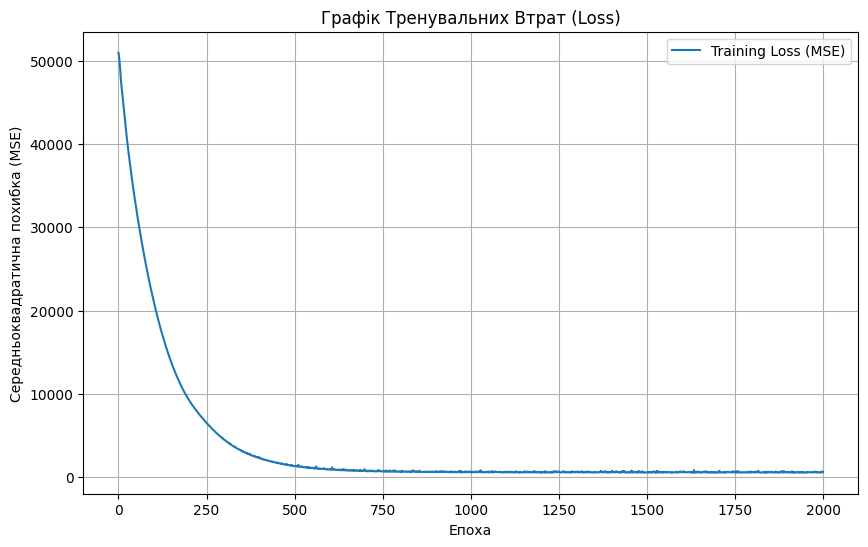

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(losses2, label='Training Loss (MSE)')
plt.title('Графік Тренувальних Втрат (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Середньоквадратична похибка (MSE)')
plt.grid(True)
plt.legend()
plt.show()

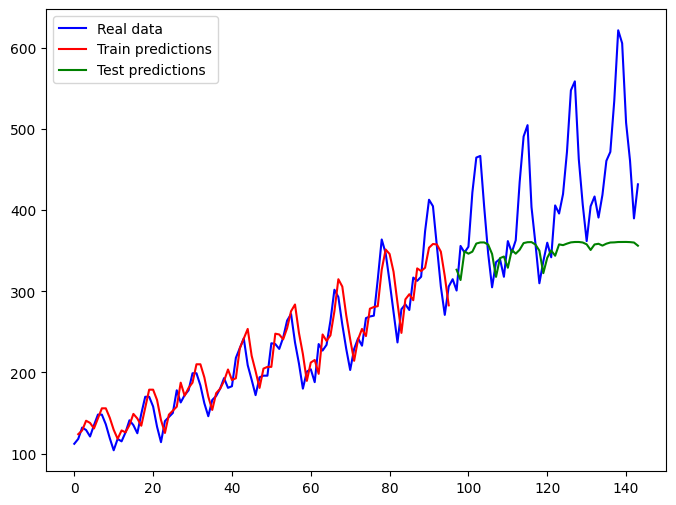

In [16]:
plot_predicts()

**Спостереження:** Показники похибок трохи покращилися, але все ще лишаються незадовільними. Користі така модель не буде мати.